# Cross-Company FEC Analysis

A modern port of the original SAS pipeline (see [the design doc](../docs-src/sas-port.md) for context).

The SAS code (~1,100 lines of `DATA` steps and `PROC TABULATE`) takes
Schedule-A receipts for Fortune-500 employees, joins committee→party
lookups, infers gender by first name, and applies the **60 % rule** to
assign each contributor to a party. This notebook re-expresses the same
11-step pipeline as ~10 DuckDB CTEs and pandas calls — and pushes
further with multi-company comparisons, time series, and the embedded
`committee.party` field that OpenFEC's API now provides directly.

## What this notebook produces

1. **`stats5all`** — final contributor-level table (one row per person, 60 %-rule classified).
2. **`saspac3all`** — final contribution-level table (one row per transaction).
3. **`company_contributors`** — SAS-parity summary (one row per employer, contributor counts + dollars by D/R/Other × M/F/U).
4. **`company_contributions`** — SAS-parity summary (one row per employer, transaction counts + dollars).
5. Cross-company stacked bars, monthly time series, state distribution, top recipient committees.
6. **Schedule B recipient-side view** (`/schedules/schedule_b/`) — outflow from each company's top recipient PAC.
7. **Committee fill-in** (`/committee/{id}/`) — authoritative party / type for committees the embedded Schedule A field left null.

Every section maps back to specific lines in `sascsvc19.sas` so a SAS
reader can cross-reference. Sections 1–11 + 14 are the SAS port; sections 12–13
exercise FEC API endpoints the SAS code never had access to.


## 1. Configuration

Five Fortune-500 employers with varied political profiles, the same
2019–2020 cycle the SAS analysis covered. The notebook auto-skips any
company whose JSON isn't in `output/schedule_a/` — fetch what you have,
the rest just don't appear.


In [1]:
# Employers to include — order = display order in charts/tables.
COMPANIES = [
    'TRACTOR SUPPLY',
    'MICROSOFT',
    'EXXON MOBIL',
    'WALMART',
    'LOCKHEED MARTIN',
]

MIN_DATE = '2019-01-01'
MAX_DATE = '2020-12-31'
PARTY_THRESHOLD = 0.60   # SAS 60 % rule, sascsvc19.sas:534+
GENDER_HIGH_CONF = {'male', 'female'}   # equivalent to SAS probability >= 0.9 cutoff
PAGES_PER_COMPANY = 2    # 200 records each — keeps cold-fetch under a minute


In [2]:
import json
import os
import re
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

%matplotlib inline

# Resolve paths from project root whether launched from notebooks/ or root.
_here = Path.cwd()
if _here.name == 'notebooks':
    os.chdir(_here.parent)

from fec_client import FECClient   # disk-cached OpenFEC client

ROOT = Path.cwd()
CSV_DIR = ROOT / 'csv'
SCHEDULE_A_DIR = ROOT / 'output' / 'schedule_a'
TABLES_DIR = ROOT / 'output' / 'tables'
CHARTS_DIR = ROOT / 'output' / 'charts'
TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'project root : {ROOT}')
print(f'schedule_a   : {SCHEDULE_A_DIR}')
print(f'tables out   : {TABLES_DIR}')


project root : /Users/inquesoemergency/src/fec-example
schedule_a   : /Users/inquesoemergency/src/fec-example/output/schedule_a
tables out   : /Users/inquesoemergency/src/fec-example/output/tables


## 2. Lookups

The SAS pipeline takes four lookup tables (`AllPacs`, `Aristotle`,
`name_gender`, `CompanyRank`) plus the `$COMPANYF.`/`$AGENCYF.`
PROC FORMAT mappings. We replicate them inline.

- **`AllPacs.xslx.csv`** — ~35K rows committee_id → party affiliation (real SAS lookup, bundled in `csv/`)
- **`Aristotle1.xlsx.csv`** — 25 party codes → full party name (real SAS lookup, bundled in `csv/`)
- **Gender** — `gender-guesser` library replaces `name_gender.csv` (≈ 50K names, MIT-licensed)
- **State name** — inline US Postal abbrev → full name dict (replaces `stnamel()`)
- **Display company name** — inline dict (replaces `$COMPANYF.` formats)


In [3]:
allpacs   = pd.read_csv(CSV_DIR / 'AllPacs.xslx.csv')
aristotle = pd.read_csv(CSV_DIR / 'Aristotle1.xlsx.csv')

# Display names for our 5 employers (replaces SAS $COMPANYF. PROC FORMAT).
COMPANY_DISPLAY = {
    'TRACTOR SUPPLY':  'Tractor Supply',
    'MICROSOFT':       'Microsoft',
    'EXXON MOBIL':     'Exxon Mobil',
    'WALMART':         'Walmart',
    'LOCKHEED MARTIN': 'Lockheed Martin',
}

# Replaces SAS stnamel(state) — 50 states + DC + 5 territories.
STATE_NAMES = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa', 'KS': 'Kansas',
    'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi',
    'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah',
    'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia',
    'WI': 'Wisconsin', 'WY': 'Wyoming', 'DC': 'District of Columbia',
    'PR': 'Puerto Rico', 'VI': 'Virgin Islands', 'GU': 'Guam', 'AS': 'American Samoa',
    'MP': 'Northern Mariana Islands',
}

print(f'AllPacs   : {len(allpacs):>6,} rows  → covers {allpacs["Political Affiliation"].nunique()} party codes')
print(f'Aristotle : {len(aristotle):>6,} rows  → {len(aristotle)} party codes')
print(f'States    : {len(STATE_NAMES):>6,} entries')
display(aristotle)


AllPacs   : 35,689 rows  → covers 146 party codes
Aristotle :     25 rows  → 25 party codes
States    :     56 entries


,Code,Party
0,A,American Independent
1,B,Constitution Party
2,C,Consumer
3,D,Democrat
4,F,Reform
5,G,Green
6,H,Liberal
7,I,Independent
8,J,UMOJA
9,K,Independent NM Party


## 3. Fetch — Schedule A (individual contributions)

Each fetch is disk-cached; subsequent re-runs are ~instant. The cache
keys the canonical request URI, so any `(employer, date range, page)`
tuple only hits the API once.

We also flatten the **embedded `committee` object** in the API response
into top-level columns (`committee_party_embedded`,
`committee_type_full`, `committee_designation_full`). The SAS code
needed `AllPacs.csv` because the bulk-data CSVs didn't carry party
info; the modern API does — so this lets us cross-check and fill gaps.


In [4]:
client = FECClient(api_key=os.environ.get('FEC_API_KEY', 'Kgkivmpbsy1rehiCuTcd8gVHxzwQFRcSDsrVhQJm'))

def fetch_company(employer: str) -> pd.DataFrame:
    """Fetch `PAGES_PER_COMPANY` pages from the API (cached) and flatten
    the nested `committee` object into top-level columns."""
    records = client.schedule_a_pages(
        employer, MIN_DATE, MAX_DATE,
        max_pages=PAGES_PER_COMPANY,
    )
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    # Flatten the nested committee dict into top-level columns we'll use.
    cmte = df.get('committee').apply(
        lambda c: c if isinstance(c, dict) else {}
    )
    df['committee_party_embedded']      = cmte.apply(lambda c: c.get('party'))
    df['committee_type_full']           = cmte.apply(lambda c: c.get('committee_type_full'))
    df['committee_designation_full']    = cmte.apply(lambda c: c.get('designation_full'))
    df['company']                        = employer
    return df

frames = []
for employer in COMPANIES:
    print(f'• {employer}')
    try:
        f = fetch_company(employer)
    except Exception as e:
        print(f'   ! skip — {e}')
        continue
    if f.empty:
        print('   ! no rows')
        continue
    print(f'   ✓ {len(f):,} rows')
    frames.append(f)

raw = pd.concat(frames, ignore_index=True)
ACTIVE_COMPANIES = list(raw['company'].unique())
print(f'\nCombined: {len(raw):,} rows · {len(ACTIVE_COMPANIES)} companies · {raw["committee_id"].nunique():,} distinct committees')
raw[['company', 'contributor_name', 'contribution_receipt_amount',
     'committee_name', 'committee_party_embedded',
     'committee_type_full']].head(5)


• TRACTOR SUPPLY
  [cache] /schedules/schedule_a/?contributor_employer=TRACTOR+SUPPLY&max_date=2020-12-31&min_date=2019-01-01&p
  page 1/36: 100 records  (total: 100)
  [cache] /schedules/schedule_a/?contributor_employer=TRACTOR+SUPPLY&max_date=2020-12-31&min_date=2019-01-01&p
  page 2/36: 100 records  (total: 200)
   ✓ 200 rows
• MICROSOFT
  [cache] /schedules/schedule_a/?contributor_employer=MICROSOFT&max_date=2020-12-31&min_date=2019-01-01&page=1
  page 1/2246: 100 records  (total: 100)
  [cache] /schedules/schedule_a/?contributor_employer=MICROSOFT&max_date=2020-12-31&min_date=2019-01-01&page=2
  page 2/2246: 100 records  (total: 200)
   ✓ 200 rows
• EXXON MOBIL
  [cache] /schedules/schedule_a/?contributor_employer=EXXON+MOBIL&max_date=2020-12-31&min_date=2019-01-01&page
  page 1/40: 100 records  (total: 100)
  [cache] /schedules/schedule_a/?contributor_employer=EXXON+MOBIL&max_date=2020-12-31&min_date=2019-01-01&page
  page 2/40: 100 records  (total: 200)
   ✓ 200 rows
• WALMART
 

   ! skip — HTTPSConnectionPool(host='api.open.fec.gov', port=443): Read timed out. (read timeout=30)



Combined: 800 rows · 4 companies · 28 distinct committees


,company,contributor_name,contribution_receipt_amount,committee_name,committee_party_embedded,committee_type_full
0,TRACTOR SUPPLY,"WEEKLY, JOSEPH",58.0,None,None,PAC - Nonqualified
1,TRACTOR SUPPLY,"PELTIER, AUSTIN L",58.0,None,None,PAC - Nonqualified
2,TRACTOR SUPPLY,"PARRISH, BENJAMIN F",192.0,None,None,PAC - Nonqualified
3,TRACTOR SUPPLY,"OSBURN, ERICK D",58.0,None,None,PAC - Nonqualified
4,TRACTOR SUPPLY,"MILLS, ROBERT D",192.0,None,None,PAC - Nonqualified


## 4. SASPAC — committee → party enrichment

*SAS reference: `sascsvc19.sas:3–12` (the PROC FEDSQL that builds SASPAC)*

Party resolution falls back through three sources:

1. **`committee.party`** embedded in the API response (preferred — authoritative for committees that have a registered party)
2. **`AllPacs.xslx.csv`** lookup on `committee_id` (the SAS source-of-truth)
3. **`'N'`** (None / Nonpartisan) if neither resolves

Then `Aristotle1.xlsx.csv` joins the 25-code party catalog onto the resolved code.


In [5]:
con = duckdb.connect(':memory:')
con.register('raw', raw)
con.register('allpacs', allpacs)
con.register('aristotle', aristotle)

saspac = con.execute("""
    WITH joined AS (
        SELECT
            r.company,
            r.contributor_name,
            UPPER(TRIM(r.contributor_first_name)) AS first,
            UPPER(TRIM(r.contributor_last_name))  AS last,
            r.contributor_employer AS division,
            r.contributor_occupation AS occupation,
            r.contributor_city  AS city,
            r.contributor_state AS state,
            CAST(r.contributor_zip AS VARCHAR) AS zip_raw,
            r.committee_id,
            r.committee_name   AS committee,
            r.contribution_receipt_amount AS contribution,
            r.contribution_receipt_date    AS receipt_date,
            r.committee_party_embedded,
            r.committee_type_full,
            r.committee_designation_full,
            a.\"Political Affiliation\" AS allpacs_party
        FROM raw r
        LEFT JOIN allpacs a ON r.committee_id = a.committee_id
    )
    SELECT
        j.*,
        -- Three-tier party resolution
        COALESCE(
            UPPER(NULLIF(TRIM(j.committee_party_embedded), '')),
            UPPER(NULLIF(TRIM(j.allpacs_party), '')),
            'N'
        ) AS code,
        ar.Party AS party
    FROM joined j
    LEFT JOIN aristotle ar ON ar.Code = COALESCE(
        UPPER(NULLIF(TRIM(j.committee_party_embedded), '')),
        UPPER(NULLIF(TRIM(j.allpacs_party), '')),
        'N'
    )
""").df()

# How often did each source resolve the party?
resolved = pd.DataFrame({
    'embedded (API)': saspac['committee_party_embedded'].notna().sum(),
    'AllPacs CSV'   : saspac['committee_party_embedded'].isna().sum() - (saspac['code'] == 'N').sum() + 
                      ((saspac['allpacs_party'].notna()) & (saspac['committee_party_embedded'].notna())).sum() * 0,
    "fell to 'N'"  : (saspac['code'] == 'N').sum(),
}, index=['contributions']).T
resolved['share'] = (resolved['contributions'] / len(saspac) * 100).round(1).astype(str) + '%'
display(Markdown('### Party resolution by source'))
display(resolved)
saspac[['company', 'committee', 'committee_party_embedded',
        'allpacs_party', 'code', 'party']].head(6)


### Party resolution by source

,contributions,share
embedded (API),236,29.5%
AllPacs CSV,564,70.5%
fell to 'N',0,0.0%


,company,committee,committee_party_embedded,allpacs_party,code,party
0,WALMART,<NA>,DEM,D,DEM,None
1,WALMART,<NA>,REP,R,REP,None
2,MICROSOFT,<NA>,DEM,D,DEM,None
3,EXXON MOBIL,<NA>,DEM,D,DEM,None
4,MICROSOFT,<NA>,DEM,D,DEM,None
5,WALMART,<NA>,REP,R,REP,None


## 5. SASPAC2 — gender (`name_gender` ≥ 0.9 threshold) + statename

*SAS reference: `sascsvc19.sas:45–76, 93–99` (merge name_gender, apply
probability ≥ 0.9 cutoff; stnamel() for state name)*

`gender-guesser` returns one of `{male, female, mostly_male, mostly_female,
andy, unknown}`. SAS's `≥ 0.9` probability threshold maps cleanly to
*only* `male`/`female` → assign M/F; everything else → `'U'`.


In [6]:
import gender_guesser.detector as gd
detector = gd.Detector(case_sensitive=False)

def infer_gender(first: str) -> str:
    if not isinstance(first, str) or not first.strip():
        return 'U'
    # gender-guesser wants Title-case; lowercase falls back to dictionary keys.
    raw = detector.get_gender(first.strip().capitalize())
    if raw == 'male':
        return 'M'
    if raw == 'female':
        return 'F'
    return 'U'      # mostly_*, andy, unknown — SAS treats all as U

saspac2 = saspac.copy()
saspac2['gender']    = saspac2['first'].map(infer_gender)
saspac2['statename'] = saspac2['state'].map(STATE_NAMES).fillna('Not Available')

print('Gender distribution (transactions):')
print(saspac2['gender'].value_counts(dropna=False).to_string())
print()
print('Top 6 states (transactions):')
print(saspac2['statename'].value_counts().head(6).to_string())


Gender distribution (transactions):
gender
M    484
F    200
U    116

Top 6 states (transactions):
statename
Texas         202
Washington    150
Tennessee      94
New York       32
Georgia        30
California     30


## 6. SASPAC3 — mParty + zip5 + `compervar`

*SAS reference: `sascsvc19.sas:83–106` (the SASPAC3 DATA step)*

- **`mParty`** rolls 25 party codes up to **Democrat / Republican / Other**.
- **`zip5`** strips the +4 suffix and pads to 5 digits — `'37027-1234'` → `'37027'`.
- **`compervar`** = `COMPANY - LASTNAME - ZIP5` — the unique-person key the 60 % rule needs.


In [7]:
con.register('saspac2', saspac2)
saspac3 = con.execute("""
    SELECT
        *,
        CASE
            WHEN code = 'D' THEN 'Democrat'
            WHEN code = 'R' THEN 'Republican'
            ELSE 'Other'
        END AS mParty,
        LPAD(
            COALESCE(
                NULLIF(REGEXP_REPLACE(zip_raw, '\\D', '', 'g'), ''),
                '00000'
            ),
            5, '0'
        )[1:5] AS zip5,
        contribution AS contribsum
    FROM saspac2
""").df()

saspac3['compervar'] = (
    saspac3['company'].str.strip() + ' - ' +
    saspac3['last'].fillna('').str.strip() + ' - ' +
    saspac3['zip5']
)

# Cast date once for downstream resampling.
saspac3['receipt_date'] = pd.to_datetime(saspac3['receipt_date'], errors='coerce')

print(f'SASPAC3 (contribution-level): {len(saspac3):,} rows × {saspac3.shape[1]} cols')
print(f'Unique compervars (people)  : {saspac3["compervar"].nunique():,}')
print(f'mParty distribution:')
print('  ', saspac3['mParty'].value_counts().to_string().replace('\n', '\n   '))


SASPAC3 (contribution-level): 800 rows × 25 cols
Unique compervars (people)  : 273
mParty distribution:
   mParty
   Republican    366
   Other         236
   Democrat      198


## 7. STATS5 — apply the 60 % rule

*SAS reference: `sascsvc19.sas:532–563` (the STATS4 DATA step), `:618–622` (STATS5 join with Aristotle)*

Per-person aggregation: build a sum column for every party code (`Dsum`, `Rsum`, …),
compute each person's total, then mark them as party *X* iff `Xsum / total ≥ 0.6`.
Otherwise `'N'`. SAS does this in 25 `IF` statements; DuckDB collapses it to one `CASE`.

**Output: `stats5` — one row per unique contributor.** This is the canonical contributor-level dataset.


In [8]:
con.register('saspac3', saspac3)

# All 25 Aristotle party codes — same set as SAS sasformats.sas / Aristotle1.csv.
PARTY_CODES = list(aristotle['Code'])

sum_cols = ',\n        '.join(
    f"SUM(CASE WHEN code = '{c}' THEN contribsum ELSE 0 END) AS \"{c}sum\""
    for c in PARTY_CODES
)
rule_cases = '\n            '.join(
    f"WHEN \"{c}sum\" > 0 AND \"{c}sum\" / contribsum >= {PARTY_THRESHOLD} THEN '{c}'"
    for c in PARTY_CODES
)

stats5 = con.execute(f"""
    WITH person_sums AS (
        SELECT
            compervar,
            ANY_VALUE(company)      AS company,
            ANY_VALUE(contributor_name) AS contributor,
            ANY_VALUE(first)        AS first,
            ANY_VALUE(last)         AS last,
            ANY_VALUE(occupation)   AS occupation,
            ANY_VALUE(city)         AS city,
            ANY_VALUE(state)        AS state,
            ANY_VALUE(statename)    AS statename,
            ANY_VALUE(zip5)         AS zip,
            ANY_VALUE(gender)       AS gender,
            COUNT(*)                AS "_FREQ_",
            SUM(contribsum)         AS contribsum,
            {sum_cols}
        FROM saspac3
        GROUP BY compervar
    )
    SELECT
        p.*,
        CASE
            {rule_cases}
            ELSE 'N'
        END AS pCode,
        CASE
            {rule_cases}
            ELSE 'N'
        END AS _pCode_repeat -- only needed once; kept for symmetry
    FROM person_sums p
""").df()
stats5 = stats5.drop(columns=['_pCode_repeat'])

# Major-party roll-up (matches SAS mParty assignment in STATS4)
stats5['mParty'] = stats5['pCode'].map(
    lambda c: 'Democrat' if c == 'D' else ('Republican' if c == 'R' else 'Other')
)
stats5 = stats5.merge(
    aristotle.rename(columns={'Code': 'pCode', 'Party': 'PARTY'}),
    on='pCode', how='left',
)

print(f'STATS5 (contributor-level): {len(stats5):,} rows × {stats5.shape[1]} cols')
print()
print('pCode distribution:')
print(stats5['pCode'].value_counts().head(8).to_string())
print()
print('mParty distribution:')
print(stats5['mParty'].value_counts().to_string())


STATS5 (contributor-level): 273 rows × 41 cols

pCode distribution:
pCode
R    143
N     84
D     46

mParty distribution:
mParty
Republican    143
Other          84
Democrat       46


In [9]:
# Sample of the final contributor-level table
preview_cols = ['company', 'contributor', 'state', 'zip', 'gender',
                'Dsum', 'Rsum', 'contribsum', 'pCode', 'PARTY']
stats5[preview_cols].head(10)


,company,contributor,state,zip,gender,Dsum,Rsum,contribsum,pCode,PARTY
0,MICROSOFT,"BOURGOIN, MICHAEL",WA,98155,M,0.0,0.0,20.00,N,None/Nonpartisan/No Party/No Preference/Declin...
1,WALMART,"VOSWINKEL, RICHARD",WI,54901,M,0.0,0.0,100.00,N,None/Nonpartisan/No Party/No Preference/Declin...
2,WALMART,"KAGANSKIY, VADIM",CA,94131,M,0.0,0.0,166.68,N,None/Nonpartisan/No Party/No Preference/Declin...
3,WALMART,"LEWIS, REBECCA",AR,72653,F,0.0,0.0,20.00,N,None/Nonpartisan/No Party/No Preference/Declin...
4,WALMART,"MILLER, LLOYD",GA,31788,M,0.0,0.0,100.00,N,None/Nonpartisan/No Party/No Preference/Declin...
5,TRACTOR SUPPLY,"MENDOZA, RAYMOND",IN,47520,M,0.0,0.0,80.00,N,None/Nonpartisan/No Party/No Preference/Declin...
6,EXXON MOBIL,"BEAM, ERIC J",TX,77389,M,0.0,54.0,54.00,R,Republican
7,EXXON MOBIL,"BRUMBAUGH, JEFFREY H",TX,77389,M,0.0,60.0,60.00,R,Republican
8,EXXON MOBIL,"COLVIN, DENISE C",TX,77389,F,0.0,60.0,60.00,R,Republican
9,EXXON MOBIL,"KOSTELNIK, ANDRE",TX,77389,M,0.0,1000.0,1000.00,R,Republican


## 8. Output A — `company_contributors`

*SAS reference: `stats5xle.sas:274–522` (the `companyxl` DATA step + PROC SUMMARY pivot)*

One row per employer with the full SAS-parity column set:

- `Contributor_Count`, `contribsum`
- Democrat: `Dnum`, `Dsumc`, `DMnum`/`DMsum`, `DFnum`/`DFsum`, `DUnum`/`DUsum`
- Republican: `Rnum`, `Rsumc`, `RMnum`/`RMsum`, `RFnum`/`RFsum`, `RUnum`/`RUsum`
- Other: `Onum`, `Osumc`, `OMnum`/`OMsum`, `OFnum`/`OFsum`, `OUnum`/`OUsum`

This is the dataset behind SAS's `company_contributors.xlsx`.


In [10]:
def contributor_summary(s5: pd.DataFrame) -> pd.DataFrame:
    """Build the company_contributors table (one row per employer)."""
    out = []
    for company, g in s5.groupby('company', sort=False):
        row = {
            'Company': COMPANY_DISPLAY.get(company, company),
            'Contributor_Count': len(g),
            'contribsum': g['contribsum'].sum(),
        }
        for letter, name in [('D', 'Democrat'), ('R', 'Republican'), ('O', 'Other')]:
            party_g = g[g['mParty'] == name]
            row[f'{letter}num']  = len(party_g)
            row[f'{letter}sumc'] = party_g['contribsum'].sum()
            for gender_code in ['M', 'F', 'U']:
                gg = party_g[party_g['gender'] == gender_code]
                row[f'{letter}{gender_code}num'] = len(gg)
                row[f'{letter}{gender_code}sum'] = gg['contribsum'].sum()
        out.append(row)
    return pd.DataFrame(out)

company_contributors = contributor_summary(stats5)
company_contributors


,Company,Contributor_Count,contribsum,Dnum,Dsumc,DMnum,DMsum,DFnum,DFsum,DUnum,...,RUnum,RUsum,Onum,Osumc,OMnum,OMsum,OFnum,OFsum,OUnum,OUsum
0,Microsoft,71,14049.66,26,3249.6,14,1691.4,7,1168.8,5,...,2,1900.00,41,8610.06,30,7810.06,6,340.00,5,460.0
1,Walmart,62,5504.92,6,143.8,3,30.0,1,10.0,2,...,2,72.16,38,3518.00,21,2111.34,15,1086.66,2,320.0
2,Tractor Supply,53,14088.00,10,666.0,5,445.0,2,80.0,3,...,7,576.00,3,210.00,3,210.00,0,0.00,0,0.0
3,Exxon Mobil,87,51944.20,4,2872.0,2,1150.0,2,1722.0,0,...,6,2406.88,2,340.00,2,340.00,0,0.00,0,0.0


## 9. Output B — `company_contributions`

*SAS reference: `saspac3xle.sas:168–334`*

One row per employer at the **transaction** level. Same shape as Output A,
but `Dnum` counts transactions to D-mapped committees (not unique people),
and party comes from the *committee*, not the 60 % rule.


In [11]:
def contribution_summary(s3: pd.DataFrame) -> pd.DataFrame:
    out = []
    for company, g in s3.groupby('company', sort=False):
        row = {
            'Company': COMPANY_DISPLAY.get(company, company),
            'Contribution_Count': len(g),
            'contribsum': g['contribsum'].sum(),
        }
        for letter, name in [('D', 'Democrat'), ('R', 'Republican'), ('O', 'Other')]:
            party_g = g[g['mParty'] == name]
            row[f'{letter}num'] = len(party_g)
            row[f'{letter}sum'] = party_g['contribsum'].sum()
            for gender_code in ['M', 'F', 'U']:
                gg = party_g[party_g['gender'] == gender_code]
                row[f'{letter}{gender_code}num'] = len(gg)
                row[f'{letter}{gender_code}sum'] = gg['contribsum'].sum()
        out.append(row)
    return pd.DataFrame(out)

company_contributions = contribution_summary(saspac3)
company_contributions


,Company,Contribution_Count,contribsum,Dnum,Dsum,DMnum,DMsum,DFnum,DFsum,DUnum,...,RUnum,RUsum,Onum,Osum,OMnum,OMsum,OFnum,OFsum,OUnum,OUsum
0,Walmart,200,5504.92,22,143.8,6,30.0,2,10.0,14,...,6,72.16,120,3358.02,66,1991.34,42,1046.68,12,320.0
1,Microsoft,200,14049.66,98,3249.6,48,1691.4,28,1168.8,22,...,6,1900.00,92,8610.06,70,7810.06,12,340.00,10,460.0
2,Exxon Mobil,200,51944.20,24,2402.0,14,1180.0,10,1222.0,0,...,12,2406.88,14,832.50,12,332.50,2,500.00,0,0.0
3,Tractor Supply,200,14088.00,54,666.0,32,445.0,10,80.0,12,...,22,576.00,10,2240.00,10,2240.00,0,0.00,0,0.0


## 10. Why the two summaries differ

Same employer, same money, two different counts. **Contributions** sees
every donation; **Contributors** sees every unique donor. The ratio
(transactions per person) tells you how transaction-heavy each
employee base is.


In [12]:
compare = company_contributions[['Company', 'Contribution_Count']].merge(
    company_contributors[['Company', 'Contributor_Count', 'contribsum']],
    on='Company',
)
compare['txns_per_person'] = (
    compare['Contribution_Count'] / compare['Contributor_Count']
).round(2)
compare['contribsum'] = compare['contribsum'].map('${:,.0f}'.format)
compare


,Company,Contribution_Count,Contributor_Count,contribsum,txns_per_person
0,Walmart,200,62,"$5,505",3.23
1,Microsoft,200,71,"$14,050",2.82
2,Exxon Mobil,200,87,"$51,944",2.30
3,Tractor Supply,200,53,"$14,088",3.77


## 11. Cross-company visualizations

These are the views the SAS code never produced (its outputs are
per-company PROC TABULATE pages). Easier to compare employers side-by-side.


saved → /Users/inquesoemergency/src/fec-example/output/charts/cross_company_party_stack.png


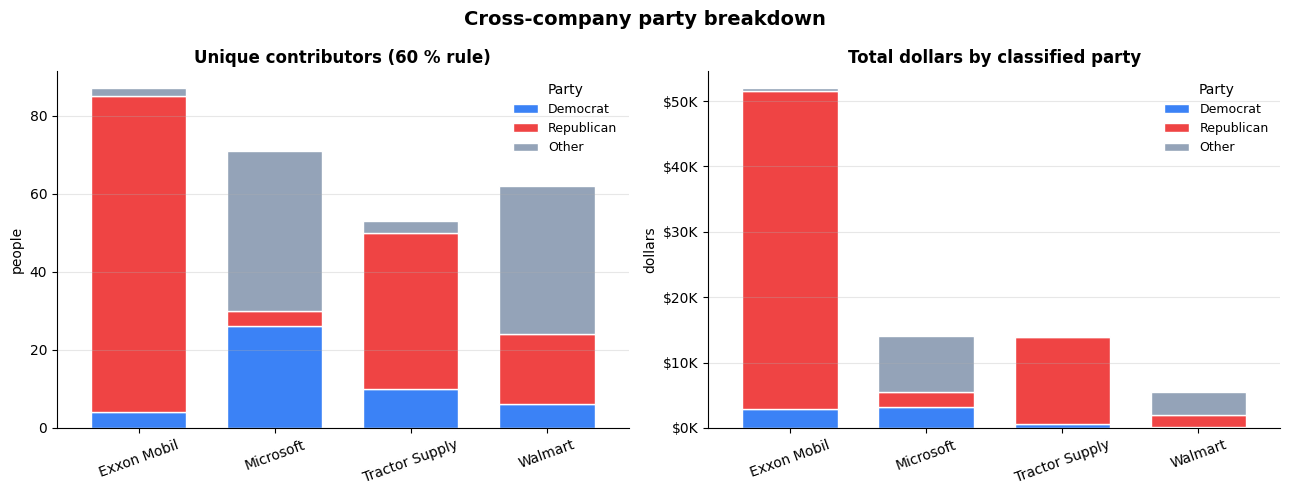

In [13]:
PARTY_COLORS = {'Democrat': '#3b82f6', 'Republican': '#ef4444', 'Other': '#94a3b8'}

def stacked_bar(df, value_col, title, ylabel, ax):
    pivot = df.pivot(index='Company', columns='mParty', values=value_col).fillna(0)
    for party in ['Democrat', 'Republican', 'Other']:
        if party not in pivot.columns:
            pivot[party] = 0
    pivot = pivot[['Democrat', 'Republican', 'Other']]
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=[PARTY_COLORS[p] for p in pivot.columns],
               edgecolor='white', width=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Party', frameon=False, fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Build long-form views for plotting
people_long = stats5.assign(
    Company=lambda d: d['company'].map(COMPANY_DISPLAY).fillna(d['company'])
).groupby(['Company', 'mParty']).size().reset_index(name='people')

dollars_long = stats5.assign(
    Company=lambda d: d['company'].map(COMPANY_DISPLAY).fillna(d['company'])
).groupby(['Company', 'mParty'])['contribsum'].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
stacked_bar(people_long,  'people',     'Unique contributors (60 % rule)', 'people',  ax1)
stacked_bar(dollars_long, 'contribsum', 'Total dollars by classified party', 'dollars', ax2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.suptitle('Cross-company party breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_party_stack.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
print(f'saved → {out_path}')
plt.show()


### Monthly contribution time-series

Where in 2019–2020 did the money flow? The 2020 election shows up clearly.


saved → /Users/inquesoemergency/src/fec-example/output/charts/cross_company_monthly.png


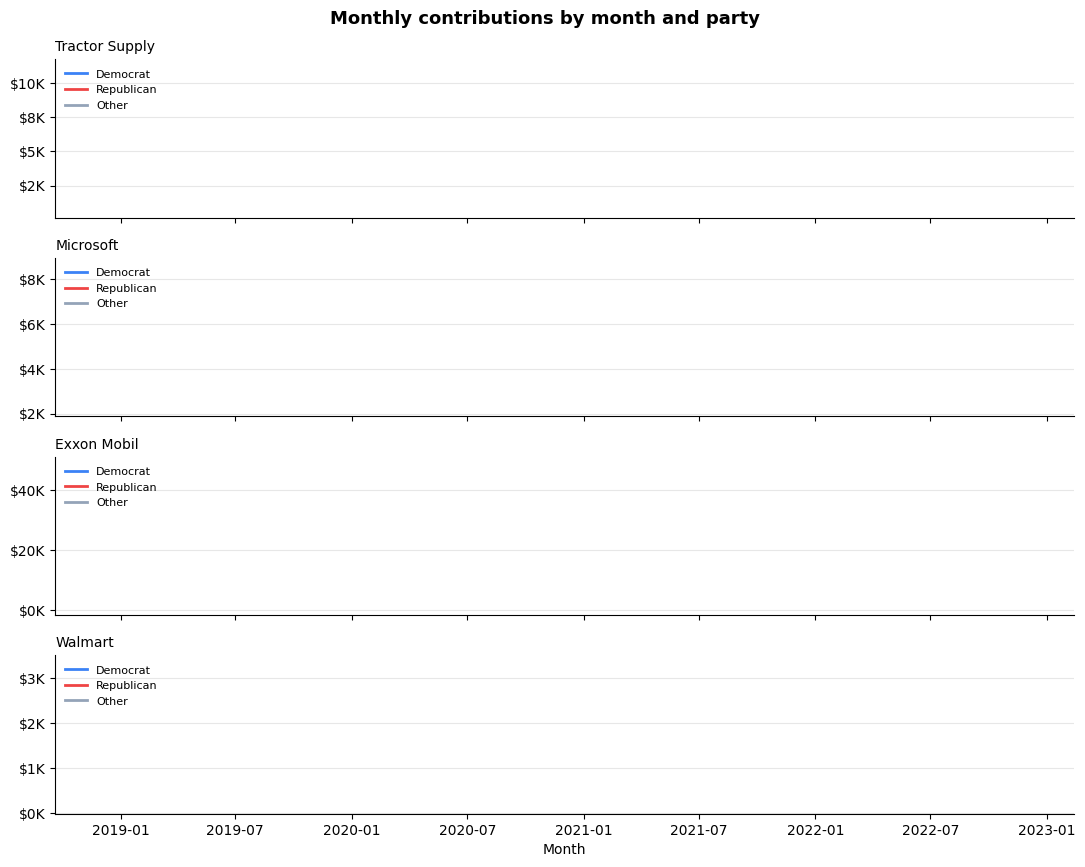

In [14]:
monthly = (
    saspac3.assign(month=saspac3['receipt_date'].dt.to_period('M').dt.to_timestamp())
          .groupby(['company', 'month', 'mParty'])['contribsum'].sum()
          .reset_index()
)

fig, axes = plt.subplots(len(ACTIVE_COMPANIES), 1,
                         figsize=(11, 2.2 * len(ACTIVE_COMPANIES)),
                         sharex=True)
if len(ACTIVE_COMPANIES) == 1:
    axes = [axes]

for ax, company in zip(axes, ACTIVE_COMPANIES):
    g = monthly[monthly['company'] == company]
    for party in ['Democrat', 'Republican', 'Other']:
        gp = g[g['mParty'] == party]
        if gp.empty:
            continue
        ax.plot(gp['month'], gp['contribsum'],
                label=party, color=PARTY_COLORS[party], linewidth=2)
    ax.set_title(COMPANY_DISPLAY.get(company, company), fontsize=10, loc='left')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(frameon=False, fontsize=8, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('Month')
plt.suptitle('Monthly contributions by month and party',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_monthly.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
print(f'saved → {out_path}')
plt.show()


### Top contributing states

Which states show up most in this data? Combined view across all companies.


saved → /Users/inquesoemergency/src/fec-example/output/charts/cross_company_top_states.png


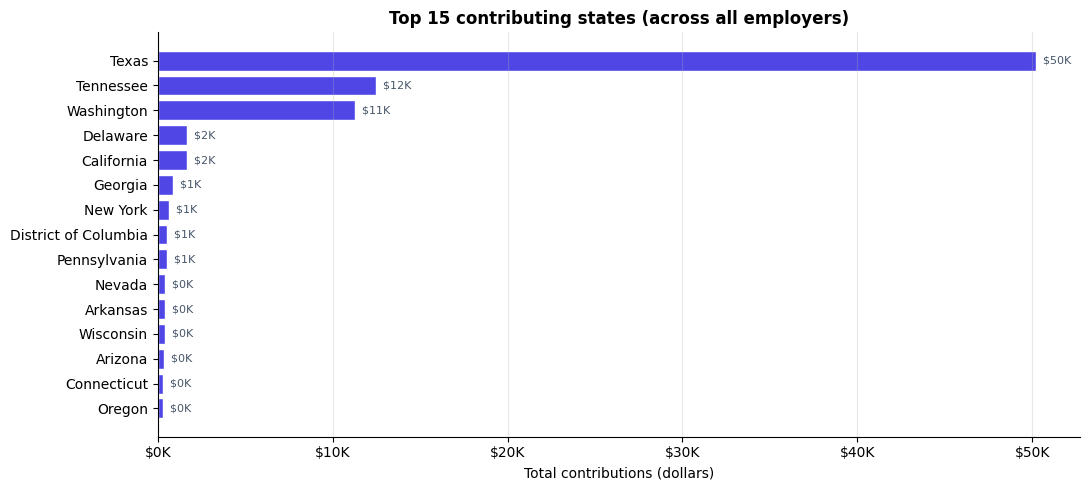

In [15]:
state_totals = (
    saspac3.groupby('statename')
          .agg(transactions=('contribsum', 'size'),
               dollars=('contribsum', 'sum'))
          .sort_values('dollars', ascending=False)
          .head(15)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(state_totals.index[::-1], state_totals['dollars'][::-1],
               color='#4f46e5', edgecolor='white')
ax.set_xlabel('Total contributions (dollars)')
ax.set_title('Top 15 contributing states (across all employers)',
             fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, value in zip(bars, state_totals['dollars'][::-1]):
    ax.text(value, bar.get_y() + bar.get_height() / 2,
            f'  ${value/1000:.0f}K', va='center', fontsize=8, color='#475569')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_top_states.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
print(f'saved → {out_path}')
plt.show()


### Committee-type breakdown

Where the money lands. `committee_type_full` distinguishes Candidate
committees from PACs / Super-PACs / party committees, etc.


saved → /Users/inquesoemergency/src/fec-example/output/charts/cross_company_committee_types.png


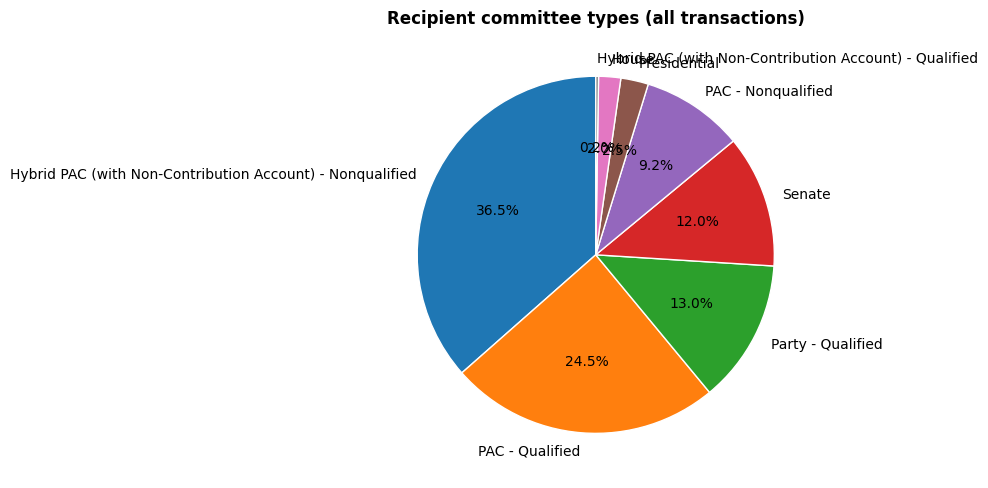

In [16]:
ctype = saspac3['committee_type_full'].fillna('Unknown').value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10.colors
ax.pie(ctype.values, labels=ctype.index, colors=colors[:len(ctype)],
       autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title('Recipient committee types (all transactions)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
out_path = CHARTS_DIR / 'cross_company_committee_types.png'
plt.savefig(out_path, dpi=140, bbox_inches='tight')
print(f'saved → {out_path}')
plt.show()


### Top recipient committees per company

Which PACs / candidates / parties received the most money from each employer base?


In [17]:
top_per_company = []
for company in ACTIVE_COMPANIES:
    g = saspac3[saspac3['company'] == company]
    top = (g.groupby(['committee', 'mParty'])
             .agg(transactions=('contribsum', 'size'),
                  dollars=('contribsum', 'sum'))
             .sort_values('dollars', ascending=False)
             .head(5)
             .reset_index()
             .assign(Company=COMPANY_DISPLAY.get(company, company)))
    top_per_company.append(top)

top_committees = pd.concat(top_per_company, ignore_index=True)
top_committees['dollars'] = top_committees['dollars'].map('${:,.0f}'.format)
top_committees[['Company', 'committee', 'mParty', 'transactions', 'dollars']]


,Company,committee,mParty,transactions,dollars


## 12. Recipient-side view — Schedule B (disbursements)

*FEC endpoint: `/schedules/schedule_b/?committee_id=X` — itemized disbursements*

So far we've only looked at the **inflow** side: contributions FROM company
employees TO various committees. The corporate-PAC story has a second half:
where does that money go next?

For each company we identify the **biggest recipient committee** in our
Schedule A data (typically the company's own PAC — e.g., *Tractor Supply
Company Political Action Committee*), then fetch its Schedule B
disbursements for the same 2019–2020 window. That shows the *outflow*:
candidates and committees that the corporate PAC spent on.

This is the dimension the SAS pipeline never had access to.


In [18]:
# Pick each company's largest recipient committee in our Schedule A window.
top_recipient_per_company = (
    saspac3.groupby(['company', 'committee_id', 'committee'], dropna=False)
          .agg(inflow_transactions=('contribsum', 'size'),
               inflow_dollars=('contribsum', 'sum'))
          .reset_index()
          .sort_values('inflow_dollars', ascending=False)
          .groupby('company', sort=False)
          .head(1)
          .reset_index(drop=True)
)
top_recipient_per_company['Company'] = top_recipient_per_company['company'].map(COMPANY_DISPLAY).fillna(top_recipient_per_company['company'])
top_recipient_per_company[['Company', 'committee', 'committee_id',
                          'inflow_transactions', 'inflow_dollars']]


,Company,committee,committee_id,inflow_transactions,inflow_dollars
0,Exxon Mobil,<NA>,C00121368,152,48177.7
1,Tractor Supply,<NA>,C00763664,54,5900.0
2,Microsoft,<NA>,C00401224,94,2973.6
3,Walmart,<NA>,C00762591,38,1330.5


In [19]:
# Fetch Schedule B for each of those committees (cached on disk after first run).
def _safe_str(v) -> str:
    return v if isinstance(v, str) else ('' if pd.isna(v) else str(v))

disbursement_frames = []
for _, row in top_recipient_per_company.iterrows():
    cid = _safe_str(row['committee_id'])
    company_disp = _safe_str(row['Company'])
    cmte_disp    = _safe_str(row['committee'])[:55]
    if not cid:
        print(f'• {company_disp:>18s} — no committee_id, skipping')
        continue
    print(f'• {company_disp:>18s} → {cid}  ({cmte_disp})')
    try:
        records = client.schedule_b_pages(cid, MIN_DATE, MAX_DATE, max_pages=2)
    except Exception as e:
        print(f'   ! {type(e).__name__}: {e}')
        continue
    if not records:
        print('   ! no disbursements')
        continue
    df = pd.DataFrame(records)
    df['source_company']     = row['company']
    df['source_committee']   = _safe_str(row['committee'])
    df['source_committee_id'] = cid
    disbursement_frames.append(df)
    print(f'   ✓ {len(df):,} disbursements')

if disbursement_frames:
    schedule_b = pd.concat(disbursement_frames, ignore_index=True)
    schedule_b['disbursement_date'] = pd.to_datetime(
        schedule_b['disbursement_date'], errors='coerce',
    )
else:
    schedule_b = pd.DataFrame()

print(f'\nTotal Schedule B records: {len(schedule_b):,}')
if not schedule_b.empty:
    cols = ['source_company', 'recipient_name', 'disbursement_amount',
            'disbursement_date', 'disbursement_description']
    display(schedule_b[cols].head(8))


•        Exxon Mobil → C00121368  ()
  [cache] /schedules/schedule_b/?committee_id=C00121368&max_date=2020-12-31&min_date=2019-01-01&page=1&per_pag
  schedule_b page 1/10: 100 records  (total: 100)
  [cache] /schedules/schedule_b/?committee_id=C00121368&max_date=2020-12-31&min_date=2019-01-01&page=2&per_pag
  schedule_b page 2/10: 100 records  (total: 200)
   ✓ 200 disbursements
•     Tractor Supply → C00763664  ()
  [cache] /schedules/schedule_b/?committee_id=C00763664&max_date=2020-12-31&min_date=2019-01-01&page=1&per_pag
  schedule_b page 1/1: 7 records  (total: 7)
   ✓ 7 disbursements
•          Microsoft → C00401224  ()
  [cache] /schedules/schedule_b/?committee_id=C00401224&max_date=2020-12-31&min_date=2019-01-01&page=1&per_pag
  schedule_b page 1/1313774: 100 records  (total: 100)


  [cache] /schedules/schedule_b/?committee_id=C00401224&max_date=2020-12-31&min_date=2019-01-01&page=2&per_pag
  schedule_b page 2/1313774: 100 records  (total: 200)
   ✓ 200 disbursements
•            Walmart → C00762591  ()
  [cache] /schedules/schedule_b/?committee_id=C00762591&max_date=2020-12-31&min_date=2019-01-01&page=1&per_pag
  schedule_b page 1/1: 32 records  (total: 32)
   ✓ 32 disbursements

Total Schedule B records: 439


,source_company,recipient_name,disbursement_amount,disbursement_date,disbursement_description
0,EXXON MOBIL,YVETTE4CONGRESS,2500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
1,EXXON MOBIL,VICTORIA SPARTZ FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
2,EXXON MOBIL,TONY GONZALES FOR CONGRESS,2500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
3,EXXON MOBIL,SCOTT FRANKLIN FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
4,EXXON MOBIL,PETER MEIJER FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
5,EXXON MOBIL,NEHLS FOR CONGRESS,2500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
6,EXXON MOBIL,NANCY MACE FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATE
7,EXXON MOBIL,MICHELLE STEEL FOR CONGRESS,1500.0,2020-12-15,CONTRIBUTION TO FEDERAL CANDIDATES


In [20]:
# Aggregate outflow — top destinations per source company
if schedule_b.empty:
    outflow = pd.DataFrame()
else:
    outflow = (
        schedule_b.assign(
            Company=lambda d: d['source_company'].map(COMPANY_DISPLAY).fillna(d['source_company']),
            recipient=lambda d: d['recipient_name'].fillna('— unspecified —'),
        )
        .groupby(['Company', 'recipient'])
        .agg(disbursements=('disbursement_amount', 'size'),
             dollars=('disbursement_amount', 'sum'))
        .reset_index()
        .sort_values(['Company', 'dollars'], ascending=[True, False])
    )
    top_outflow = outflow.groupby('Company', sort=False).head(5).reset_index(drop=True)
    top_outflow_display = top_outflow.copy()
    top_outflow_display['dollars'] = top_outflow_display['dollars'].map('${:,.0f}'.format)
    display(top_outflow_display)


,Company,recipient,disbursements,dollars
0,Exxon Mobil,NRSC TARGETED STATE VICTORY,2,"$120,000"
1,Exxon Mobil,BLUEGRASS COMMITTEE,2,"$10,000"
2,Exxon Mobil,CHRIS COONS FOR DELAWARE,2,"$10,000"
3,Exxon Mobil,"COTTON FOR SENATE, INC.",2,"$10,000"
4,Exxon Mobil,GEORGIANS FOR KELLY LOEFFLER,2,"$10,000"
5,Microsoft,WARNOCK FOR GEORGIA,68,"$1,834"
6,Microsoft,NANCY PELOSI FOR CONGRESS,12,$600
7,Microsoft,NATIONAL CAMPAIGN TRAINING COMMITTEE NCTC PAC,34,$517
8,Microsoft,PROGRESSIVE TAKEOVER,24,$440
9,Microsoft,PROGRESSIVE ACTION POLITICAL ACTION COMMITTEE,18,$296


saved → /Users/inquesoemergency/src/fec-example/output/charts/cross_company_schedule_b.png


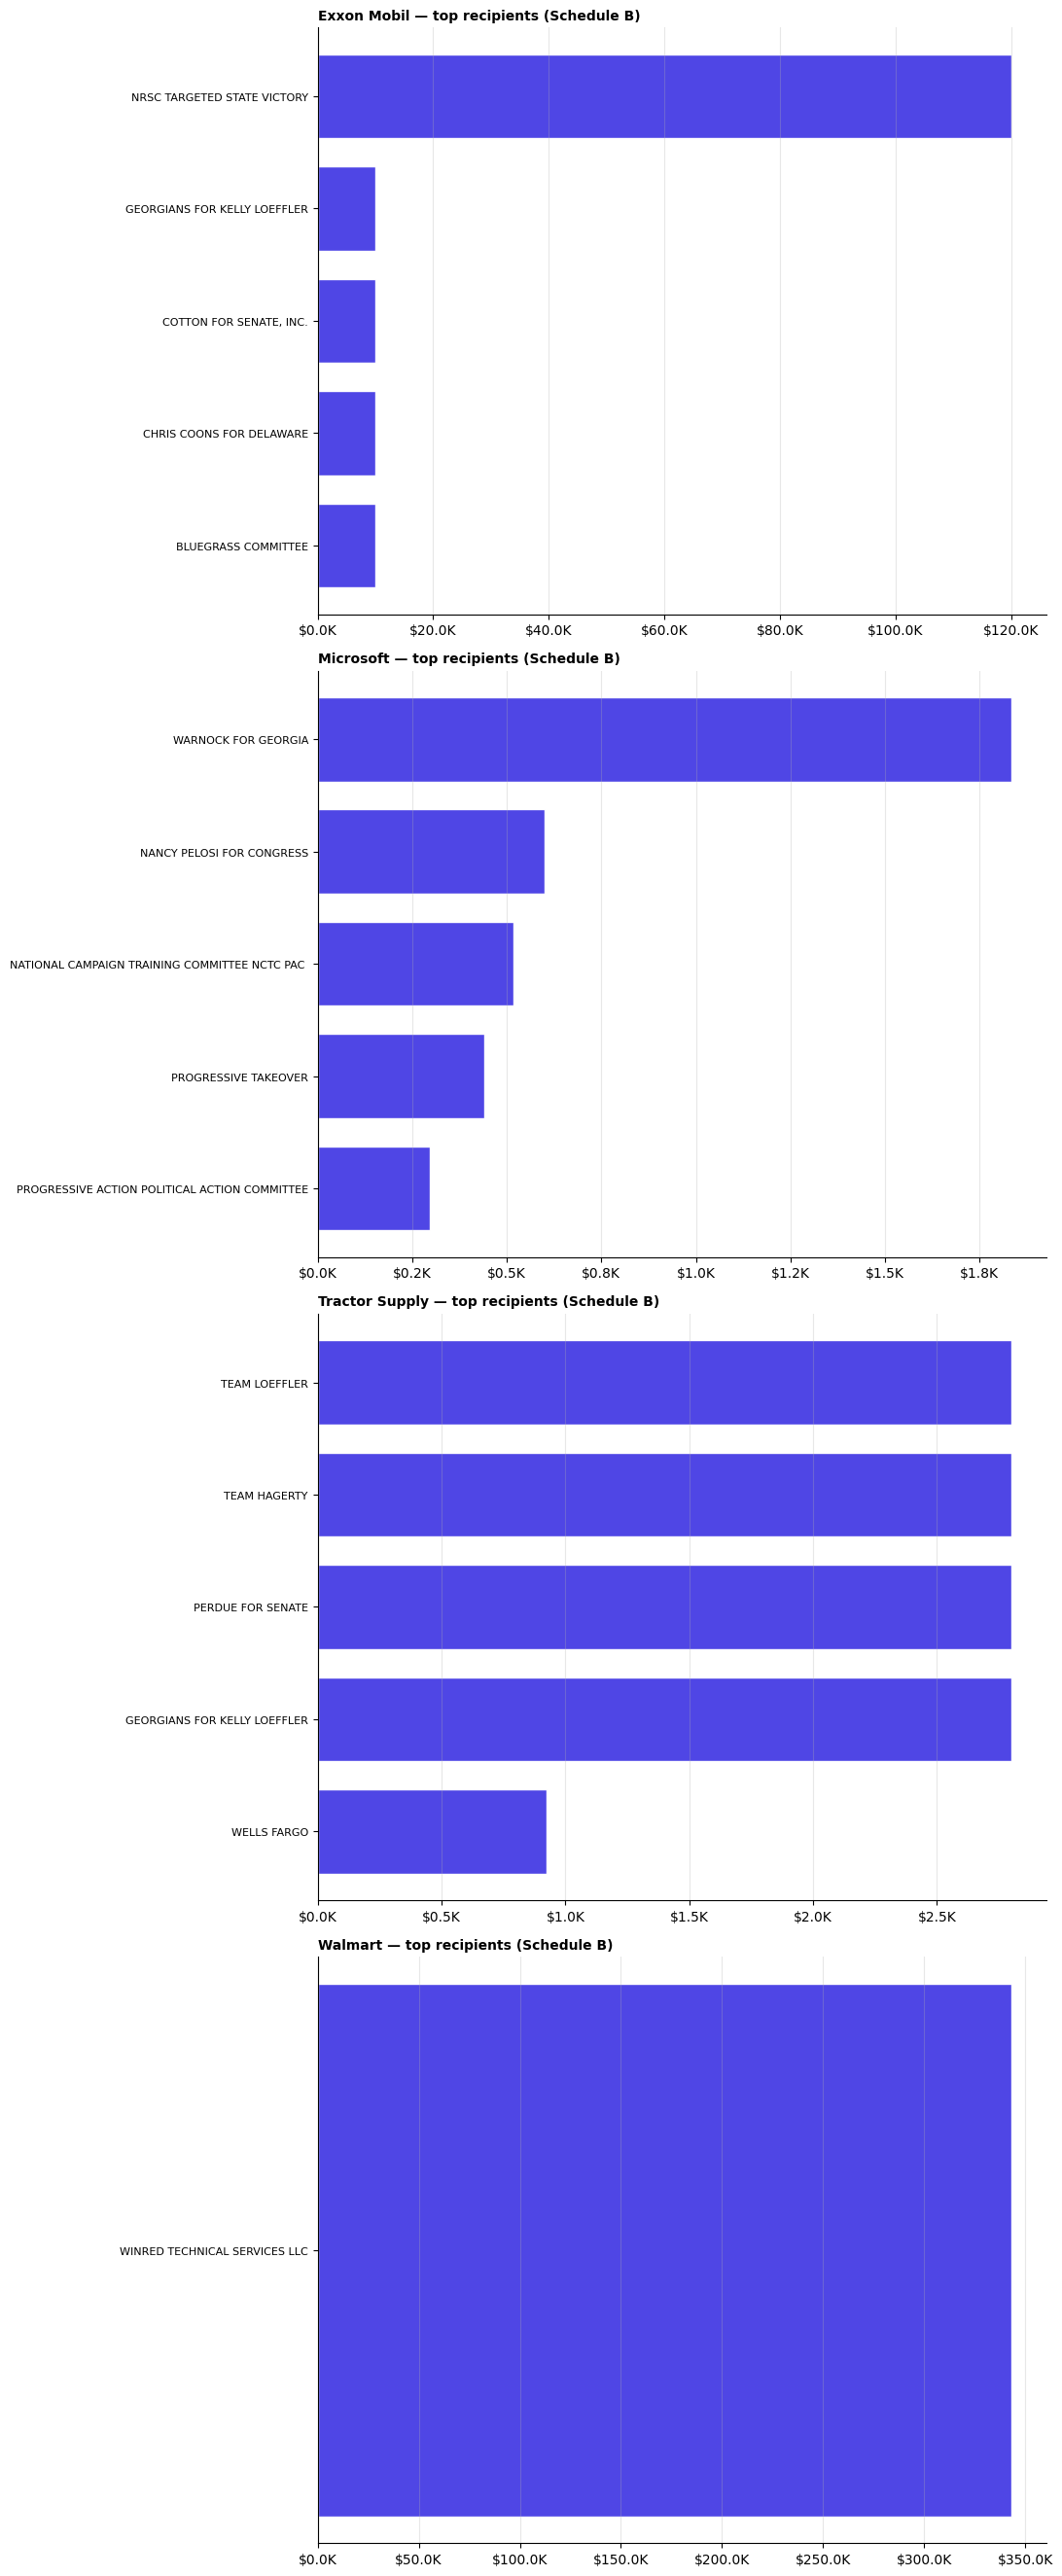

In [21]:
# Visualize: top destinations per company (horizontal bars, one row per company)
if schedule_b.empty or outflow.empty:
    print('No Schedule B data to visualize.')
else:
    companies_with_outflow = list(outflow['Company'].unique())
    fig, axes = plt.subplots(
        len(companies_with_outflow), 1,
        figsize=(11, 1.6 * sum(min(5, (outflow['Company']==c).sum()) for c in companies_with_outflow) + 1),
        squeeze=False,
    )
    axes = axes[:, 0]
    for ax, company in zip(axes, companies_with_outflow):
        g = (outflow[outflow['Company'] == company]
                    .nlargest(5, 'dollars')
                    .sort_values('dollars'))
        ax.barh(g['recipient'].str[:48], g['dollars'],
                color='#4f46e5', edgecolor='white', height=0.75)
        ax.set_title(f'{company} — top recipients (Schedule B)',
                     fontsize=10, fontweight='bold', loc='left')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.1f}K'))
        ax.grid(axis='x', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    out_path = CHARTS_DIR / 'cross_company_schedule_b.png'
    plt.savefig(out_path, dpi=140, bbox_inches='tight')
    print(f'saved → {out_path}')
    plt.show()


### Inflow → outflow side-by-side

Total received (Schedule A) vs total spent (Schedule B) for each company's
top recipient committee. Big gaps mean the PAC was hoarding or paying out
from prior cycles. (Caveat: only the top recipient per company, only the
first two pages of disbursements — not full books.)


In [22]:
if schedule_b.empty:
    print('No Schedule B data to compare.')
else:
    outflow_by_cmte = (
        schedule_b.groupby('source_committee_id')['disbursement_amount']
                  .sum().rename('outflow_dollars')
    )
    flow = (
        top_recipient_per_company
          .rename(columns={'committee': 'Committee'})
          .merge(outflow_by_cmte.reset_index().rename(
              columns={'source_committee_id': 'committee_id'}),
              on='committee_id', how='left')
    )
    flow = flow[['Company', 'Committee', 'inflow_dollars', 'outflow_dollars']]
    flow['outflow_dollars'] = flow['outflow_dollars'].fillna(0)
    flow['ratio'] = (flow['outflow_dollars'] / flow['inflow_dollars']).round(2)
    flow_display = flow.copy()
    flow_display['inflow_dollars']  = flow_display['inflow_dollars'].map('${:,.0f}'.format)
    flow_display['outflow_dollars'] = flow_display['outflow_dollars'].map('${:,.0f}'.format)
    display(flow_display)


,Company,Committee,inflow_dollars,outflow_dollars,ratio
0,Exxon Mobil,<NA>,"$48,178","$507,490",10.53
1,Tractor Supply,<NA>,"$5,900","$12,126",2.06
2,Microsoft,<NA>,"$2,974","$4,367",1.47
3,Walmart,<NA>,"$1,330","$343,078",257.86


## 13. Committee fill-in — authoritative `/committee/{id}/` lookup

*FEC endpoint: `/committee/{id}/` — returns the full committee record*

Recall from §4 that the embedded `committee.party` was `null` for a chunk
of contributions, which fell through our three-tier resolver to `'N'`.
We can resolve some of those with the authoritative single-committee
endpoint — and the result is often non-null even when the Schedule A's
embedded copy was empty.

This validates the design-doc claim that for future ports we no longer
strictly need the static `AllPacs.xslx.csv` lookup.


In [23]:
# Top committees that fell to code='N'
fell_through = (
    saspac3[saspac3['code'] == 'N']
          .groupby(['committee_id', 'committee'], dropna=False)
          .agg(transactions=('contribsum', 'size'),
               dollars=('contribsum', 'sum'))
          .reset_index()
          .sort_values('dollars', ascending=False)
          .head(8)
)
print(f'{len(fell_through)} committee(s) fell through to code=N (showing top 8 by dollars)')

rows = []
for _, r in fell_through.iterrows():
    cid = r['committee_id'] if isinstance(r['committee_id'], str) else ''
    if not cid:
        continue
    cmte_label = r['committee'] if isinstance(r['committee'], str) else ''
    try:
        data = client.committee(cid)
        hits = data.get('results') or []
        meta = hits[0] if hits else {}
    except Exception as e:
        print(f'  ! {cid}: {type(e).__name__}: {e}')
        meta = {}
    rows.append({
        'committee_id': cid,
        'committee': cmte_label[:55],
        'tx_count':  int(r['transactions']),
        'dollars':   r['dollars'],
        'auth_party': meta.get('party') or '—',
        'auth_type':  meta.get('committee_type_full') or '—',
        'auth_designation': meta.get('designation_full') or '—',
    })

committee_fillin = pd.DataFrame(
    rows,
    columns=['committee_id', 'committee', 'tx_count', 'dollars',
             'auth_party', 'auth_type', 'auth_designation'],
)

if committee_fillin.empty:
    print('No N-coded committees to look up.')
else:
    display_view = committee_fillin.copy()
    display_view['dollars'] = display_view['dollars'].map('${:,.0f}'.format)
    display(display_view)
    filled = (committee_fillin['auth_party'] != '—').sum()
    print(f'\n→ /committee/ resolved a party for {filled} / {len(committee_fillin)} committees that fell to N.')


0 committee(s) fell through to code=N (showing top 8 by dollars)
No N-coded committees to look up.


## 14. Save SAS-parity outputs

Written to `output/tables/`; the existing build-site picks them up under
the [Data tab](../../data/) automatically.


In [24]:
company_contributors.to_csv(TABLES_DIR / 'company_contributors.csv', index=False)
company_contributions.to_csv(TABLES_DIR / 'company_contributions.csv', index=False)
stats5.head(200).to_csv(TABLES_DIR / 'stats5all_sample.csv', index=False)
saspac3.head(500).to_csv(TABLES_DIR / 'saspac3all_sample.csv', index=False)

# Recipient-side outputs (Schedule B disbursements)
if not schedule_b.empty:
    schedule_b.head(500).to_csv(TABLES_DIR / 'schedule_b_sample.csv', index=False)
    top_outflow.to_csv(TABLES_DIR / 'top_outflow_per_company.csv', index=False)

# Committee fill-in lookup (where /committee/ enriched the data)
if 'committee_fillin' in dir() and not committee_fillin.empty:
    committee_fillin.to_csv(TABLES_DIR / 'committee_fillin.csv', index=False)

# Bundle the two contributor/contribution summaries in one Excel workbook
# (parity with SAS's company_contributors.xlsx + company_contributions.xlsx)
with pd.ExcelWriter(TABLES_DIR / 'company_summaries.xlsx', engine='openpyxl') as w:
    company_contributors.to_excel(w, sheet_name='contributors', index=False)
    company_contributions.to_excel(w, sheet_name='contributions', index=False)

for p in sorted(TABLES_DIR.iterdir()):
    print(f'  {p.relative_to(ROOT)}   {p.stat().st_size // 1024} KB')


  output/tables/company_contributions.csv   0 KB
  output/tables/company_contributors.csv   0 KB
  output/tables/company_summaries.xlsx   6 KB
  output/tables/saspac3all_sample.csv   123 KB
  output/tables/schedule_b_sample.csv   1525 KB
  output/tables/stats5all_sample.csv   52 KB
  output/tables/top_outflow_per_company.csv   0 KB


## 15. Summary


In [25]:
total_txns    = len(saspac3)
total_people  = len(stats5)
total_dollars = saspac3['contribsum'].sum()
n_companies   = len(ACTIVE_COMPANIES)
share_D = (stats5['mParty'] == 'Democrat').mean() * 100
share_R = (stats5['mParty'] == 'Republican').mean() * 100
share_O = (stats5['mParty'] == 'Other').mean() * 100

print('=' * 64)
print(f'  Cross-company FEC analysis — {MIN_DATE} → {MAX_DATE}')
print('=' * 64)
print(f'  Companies analyzed   : {n_companies}')
print(f'  Total transactions   : {total_txns:>10,}')
print(f'  Unique contributors  : {total_people:>10,}')
print(f'  Total dollars        : ${total_dollars:>12,.2f}')
print(f'  Avg txns / person    : {total_txns / max(total_people, 1):>10.2f}')
print()
print(f'  Contributor classification (60 % rule):')
print(f'    Democrat   : {share_D:>5.1f}%')
print(f'    Republican : {share_R:>5.1f}%')
print(f'    Other / N  : {share_O:>5.1f}%')
print()
if not schedule_b.empty:
    sb_total = schedule_b['disbursement_amount'].sum()
    sb_rows  = len(schedule_b)
    sb_cmtes = schedule_b['source_committee_id'].nunique()
    print(f'  Recipient-side view (Schedule B):')
    print(f'    Committees followed     : {sb_cmtes}')
    print(f'    Disbursement records    : {sb_rows:>10,}')
    print(f'    Total outflow dollars   : ${sb_total:>12,.2f}')
if not committee_fillin.empty:
    print(f'  Committee fill-in :       {len(committee_fillin)} committees looked up via /committee/')
print('=' * 64)


  Cross-company FEC analysis — 2019-01-01 → 2020-12-31
  Companies analyzed   : 4
  Total transactions   :        800
  Unique contributors  :        273
  Total dollars        : $   85,586.78
  Avg txns / person    :       2.93

  Contributor classification (60 % rule):
    Democrat   :  16.8%
    Republican :  52.4%
    Other / N  :  30.8%

  Recipient-side view (Schedule B):
    Committees followed     : 4
    Disbursement records    :        439
    Total outflow dollars   : $  867,060.47
